# Section 2.2 - Spectacular Growth of AI-Related Trade
Generates: figures/ai-trade-index.pdf/png, figures/ai-trade-share.pdf/png.
**Run after 06** - appends to tables/ai-trade-results.tex.


In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [2]:
# Define paths for output files
texfile = "../paper/tables/ai-trade-results.tex"
figfile = "../paper/figures/"

In [3]:
matlist = pd.read_csv('../data-input/hs10_classification_final_v3.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [4]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [5]:
df = pd.read_parquet('../data-input/TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [6]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2726615,TOTAL FOR ALL COUNTRIES,1031361,308288,1605514000,"OYSTERS, SMOKED",2026-01-01,HS10,16,1605,1031361.0,308288.0
2726616,TOTAL FOR ALL COUNTRIES,582408,92228,1605515000,"OYSTERS EXCEPT SMOKED, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,582408.0,92228.0
2726617,TOTAL FOR ALL COUNTRIES,310800,36176,1605520500,SCALLOP PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,310800.0,36176.0
2726618,TOTAL FOR ALL COUNTRIES,412467,91158,1605526000,"SCALLOPS, PREPARED OR PRESERVED",2026-01-01,HS10,16,1605,412467.0,91158.0
2726619,TOTAL FOR ALL COUNTRIES,368316,37195,1605530500,MUSSEL PRODUCTS WITH FISH MEAT; PREP MEALS,2026-01-01,HS10,16,1605,368316.0,37195.0


In [7]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [8]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty,relevance,primary_category,reasoning
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,0602,773010.0,0.0,Low,Not_DC_Related,Roses are ornamental plants used for landscapi...
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,0602,6177543.0,0.0,Low,Not_DC_Related,Live orchid plants are ornamental/decorative p...
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,0602,135786.0,0.0,Low,Not_DC_Related,These are live flowering plants (chrysanthemum...
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,0602,169439.0,0.0,Low,Not_DC_Related,This product is live herbaceous perennial plan...
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,0602,2177498.0,25345.0,Low,Not_DC_Related,Live herbaceous perennial plants from nurserie...


In [9]:
grp = df.groupby(['relevance', 'time'], observed=True)

grp_sum = grp[['imports']].sum().reset_index()

grp = df.groupby(['time'], observed=True)

grp_total = grp[['imports']].sum().reset_index()

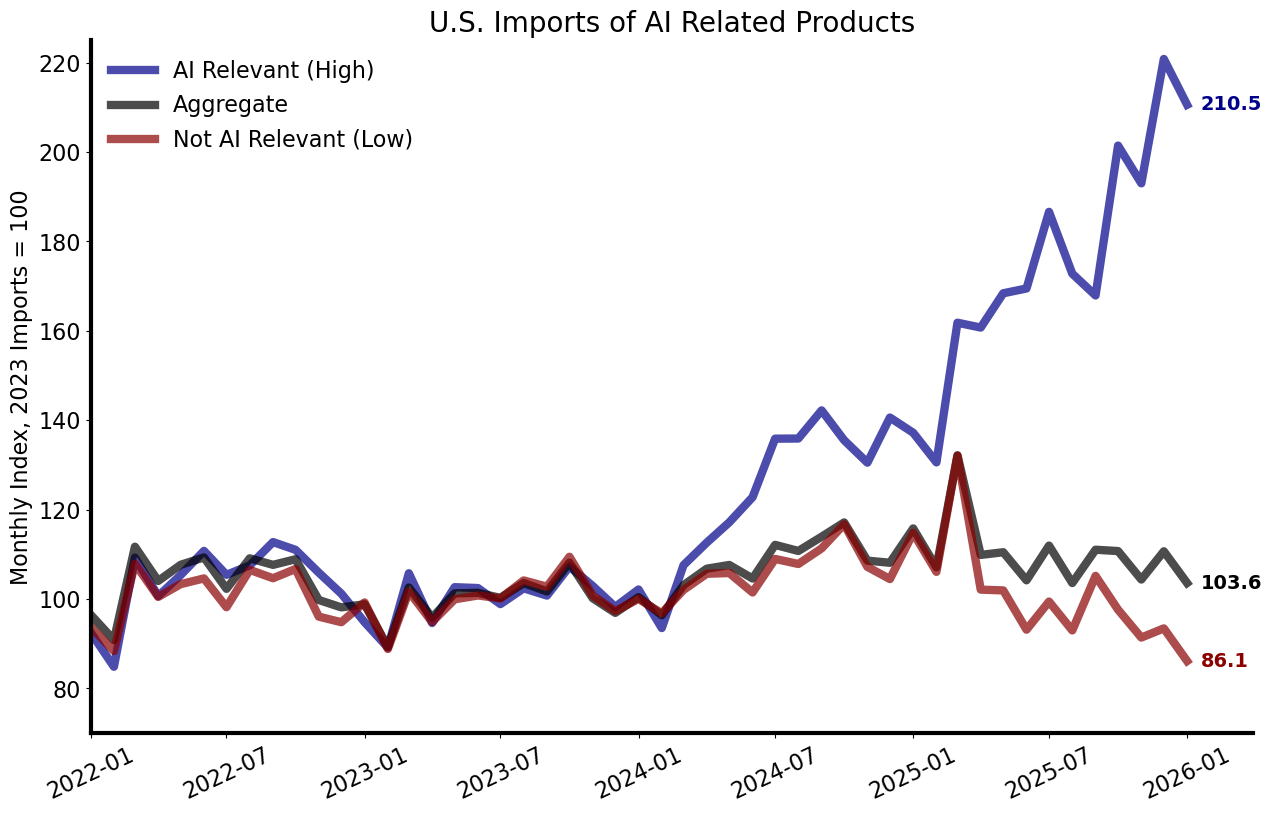

In [10]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["imports"] / foo3["imports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Add annotations for last observations
last_date_ai = foo.index[-1]
last_value_ai = 100*(12*foo["imports"].iloc[-1] / foo["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_ai:.1f}', 
            xy=(last_date_ai, last_value_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkblue',
            va='center')

last_date_agg = foo2.index[-1]
last_value_agg = 100*(12*foo2["imports"].iloc[-1] / foo2["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_agg:.1f}', 
            xy=(last_date_agg, last_value_agg),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='black',
            va='center')

last_date_not_ai = foo3.index[-1]
last_value_not_ai = 100*(12*foo3["imports"].iloc[-1] / foo3["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_not_ai:.1f}', 
            xy=(last_date_not_ai, last_value_not_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkred',
            va='center')

ax.set_title("U.S. Imports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2026,3,30)])

ax.set_ylim(70,225)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

plt.savefig(figfile+"ai-trade-index.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-trade-index.pdf", bbox_inches = "tight")

plt.show()

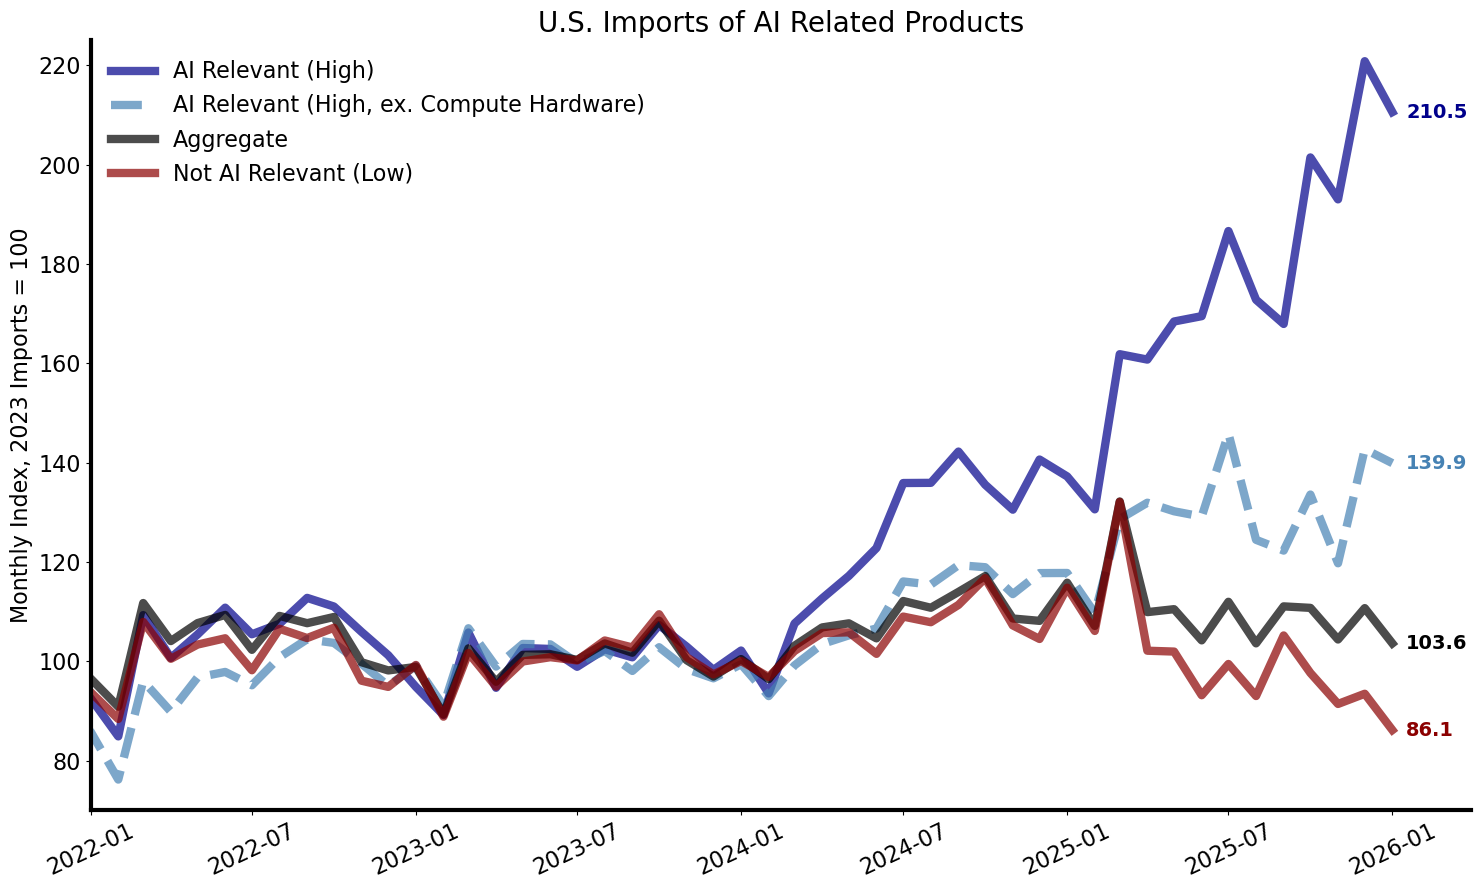

In [11]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

# High relevance, excluding Compute Hardware
foo_ex = (
    df[(df['relevance'] == 'High') & (df['primary_category'] != 'Compute_Hardware')]
    .groupby('time', observed=True)[['imports']].sum()
)
ax.plot(foo_ex.index, 100*(12*foo_ex["imports"] / foo_ex["imports"].loc["2023"].sum()) ,
        color = "steelblue", alpha = 0.7, linewidth = 6, linestyle='--',
        label='AI Relevant (High, ex. Compute Hardware)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["imports"] / foo3["imports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Annotations for last observations
for series, color, label_text in [
    (foo,    "darkblue",  None),
    (foo_ex, "steelblue", None),
    (foo2,   "black",     None),
    (foo3,   "darkred",   None),
]:
    base = foo["imports"].loc["2023"].sum() if series is foo else \
           foo_ex["imports"].loc["2023"].sum() if series is foo_ex else \
           foo2["imports"].loc["2023"].sum() if series is foo2 else \
           foo3["imports"].loc["2023"].sum()
    last_date  = series.index[-1]
    last_value = 100 * (12 * series["imports"].iloc[-1] / base)
    ax.annotate(f'{last_value:.1f}',
                xy=(last_date, last_value),
                xytext=(10, 0), textcoords='offset points',
                fontsize=14, fontweight='bold', color=color,
                va='center')

ax.set_title("U.S. Imports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2026,3,30)])

ax.set_ylim(70, 225)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

plt.tight_layout()
plt.show()


In [12]:
# Export the three series to CSV
import os

# Create data-output directory if it doesn't exist
os.makedirs('data-output', exist_ok=True)

# Prepare the three series with the same transformations as in the plot
# AI Relevant (High relevance)
ai_relevant = grp_sum[grp_sum['relevance']=='High'].copy()
ai_relevant.set_index('time', inplace=True)
ai_relevant_index = 100*(12*ai_relevant["imports"] / ai_relevant["imports"].loc["2023"].sum())

# Aggregate
aggregate = grp_total.copy()
aggregate.set_index('time', inplace=True)
aggregate_index = 100*(12*aggregate["imports"] / aggregate["imports"].loc["2023"].sum())

# Not AI Relevant (Low relevance)
not_ai_relevant = grp_sum[grp_sum['relevance']=='Low'].copy()
not_ai_relevant.set_index('time', inplace=True)
not_ai_relevant_index = 100*(12*not_ai_relevant["imports"] / not_ai_relevant["imports"].loc["2023"].sum())

# Combine into a single DataFrame
export_df = pd.DataFrame({
    'date': ai_relevant_index.index,
    'AI_Relevant': ai_relevant_index.values,
    'Aggregate': aggregate_index.values,
    'Not_AI_Relevant': not_ai_relevant_index.values
})

# Filter to only include data from 2023 onwards
export_df = export_df[export_df['date'] >= '2023-01-01']

# Save to CSV
output_file = '../data-output/ai_trade_index_series.csv'
export_df.to_csv(output_file, index=False)

print(f"Successfully exported three series to {output_file}")
print(f"\nPreview of exported data:")
print(export_df.head())
print(f"\n... {len(export_df)} rows total")

Successfully exported three series to ../data-output/ai_trade_index_series.csv

Preview of exported data:
          date  AI_Relevant   Aggregate  Not_AI_Relevant
120 2023-01-01    94.831089   98.841990        99.241206
121 2023-02-01    89.147320   89.280026        88.825185
122 2023-03-01   105.770916  102.582313       101.666095
123 2023-04-01    94.639069   95.852326        94.872130
124 2023-05-01   102.653518  101.268108        99.936208

... 37 rows total


In [13]:
# Write key values to LaTeX file
with open(texfile, 'a') as f:
    f.write(f'\\def\\aiRelevantIndex{{{last_value_ai:.0f}}} % AI-relevant imports index (2023=100)\n')
    f.write(f'\\def\\aggregateIndex{{{last_value_agg:.0f}}} % Aggregate imports index (2023=100)\n')
    f.write(f'\\def\\notAiRelevantIndex{{{last_value_not_ai:.0f}}} % Non-AI-relevant imports index (2023=100)\n')
    f.write(f'\\def\\lastObsDate{{{last_date_ai.strftime("%B %Y")}}} % Last observation date\n')

print(f"Written to {texfile}:")
print(f"  AI Relevant Index: {last_value_ai:.0f}")
print(f"  Aggregate Index: {last_value_agg:.0f}")
print(f"  Not AI Relevant Index: {last_value_not_ai:.0f}")
print(f"  Last Observation: {last_date_ai.strftime('%B %Y')}")

Written to ../paper/tables/ai-trade-results.tex:
  AI Relevant Index: 211
  Aggregate Index: 104
  Not AI Relevant Index: 86
  Last Observation: January 2026


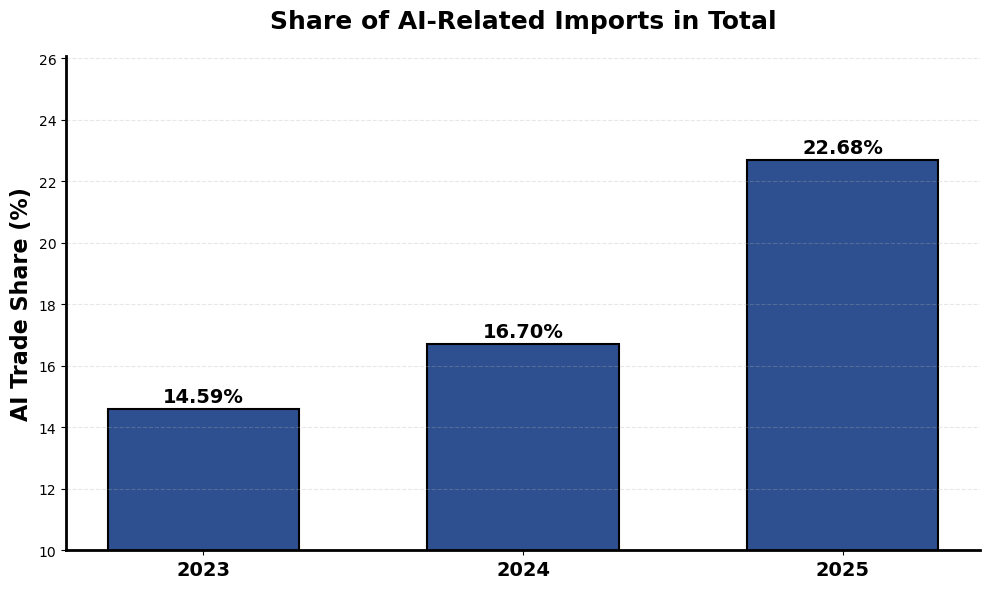


AI Trade Share:
  2023: 14.59%
  2024: 16.70%
  2025: 22.68%

Growth: 8.09 percentage points


In [14]:
# Calculate AI trade share for each year (2023-2025)
years = [2023, 2024, 2025]
ai_shares = []

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index("time", inplace=True)
df.set_index("time", inplace=True)

for year in years:
    year_str = str(year)
    total_trade = df.imports.loc[year_str].sum()
    ai_trade = foo.imports.loc[year_str].sum()
    ai_share = (ai_trade / total_trade) * 100
    ai_shares.append(ai_share)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(years, ai_shares, color='#2E5090', edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for i, (year, share) in enumerate(zip(years, ai_shares)):
    ax.text(year, share + 0.1, f'{share:.2f}%', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
# ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('AI Trade Share (%)', fontsize=16, fontweight='bold')
ax.set_title('Share of AI-Related Imports in Total', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(years)
ax.set_ylim(10, max(ai_shares) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()

plt.savefig(figfile+"ai-trade-share.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-trade-share.pdf", bbox_inches = "tight")

plt.show()

print(f"\nAI Trade Share:")
for year, share in zip(years, ai_shares):
    print(f"  {year}: {share:.2f}%")
print(f"\nGrowth: {ai_shares[-1] - ai_shares[0]:.2f} percentage points")

In [15]:
# Write AI trade share values to LaTeX file
with open(texfile, 'a') as f:
    f.write(f'\\def\\aiShareTwentyThree{{{ai_shares[0]:.0f}}} % AI share of total imports in 2023 (%)\n')
    f.write(f'\\def\\aiShareTwentyFour{{{ai_shares[1]:.0f}}} % AI share of total imports in 2024 (%)\n')
    f.write(f'\\def\\aiShareTwentyFive{{{ai_shares[2]:.0f}}} % AI share of total imports in 2025 (%)\n')
    f.write(f'\\def\\aiShareGrowth{{{(ai_shares[-1] - ai_shares[0]):.0f}}} % AI share growth 2023-2025 (percentage points)\n')

print(f"\nAppended AI share values to {texfile}:")
print(f"  2023: {ai_shares[0]:.0f}%")
print(f"  2024: {ai_shares[1]:.0f}%")
print(f"  2025: {ai_shares[2]:.0f}%")
print(f"  Growth: {(ai_shares[-1] - ai_shares[0]):.0f} percentage points")


Appended AI share values to ../paper/tables/ai-trade-results.tex:
  2023: 15%
  2024: 17%
  2025: 23%
  Growth: 8 percentage points


In [16]:
# DATA PREPARATION: Calculate shares and prepare data for category comparisons

# Get all categories except Not_DC_Related
ai_categories = [cat for cat in matlist['primary_category'].unique() 
                 if cat != 'Not_DC_Related' and pd.notna(cat)]
ai_categories = sorted(ai_categories)

# Calculate total high AI trade and share for each category
df_reset = df.reset_index()
high_ai_total = df_reset[df_reset['relevance'] == 'High']['imports'].sum()

category_shares = {}
for cat in ai_categories:
    cat_data = df_reset[(df_reset['primary_category'] == cat) & 
                        (df_reset['relevance'] == 'High')]
    cat_imports = cat_data['imports'].sum()
    share = (cat_imports / high_ai_total) * 100
    category_shares[cat] = share

# Sort by share (descending) and take top 8
top_categories = sorted(category_shares.items(), key=lambda x: x[1], reverse=True)[:8]

# Create grouped data for plotting - ONLY HIGH RELEVANCE for AI categories
df_high = df_reset[df_reset['relevance'] == 'High'].copy()
grp_cat = df_high.groupby(['primary_category', 'time'], observed=True)
grp_cat_sum = grp_cat[['imports']].sum().reset_index()

# Get Not_DC_Related data (all relevance levels)
not_dc_all = df_reset[df_reset['primary_category'] == 'Not_DC_Related'].copy()
grp_not_dc = not_dc_all.groupby(['time'], observed=True)
not_dc_sum = grp_not_dc[['imports']].sum().reset_index()
not_dc_sum.set_index('time', inplace=True)

print("\nAI Category Shares of Total High AI Trade:")
for cat, share in top_categories:
    print(f"  {cat.replace('_', ' ')}: {share:.2f}%")


AI Category Shares of Total High AI Trade:
  Compute Hardware: 47.39%
  Electrical Power: 26.30%
  Networking Telecom: 12.87%
  Cooling HVAC: 10.61%
  Building Structure: 2.52%
  Fire Safety Security: 0.19%
  Specialty Materials: 0.12%
  Maintenance Operations: 0.00%


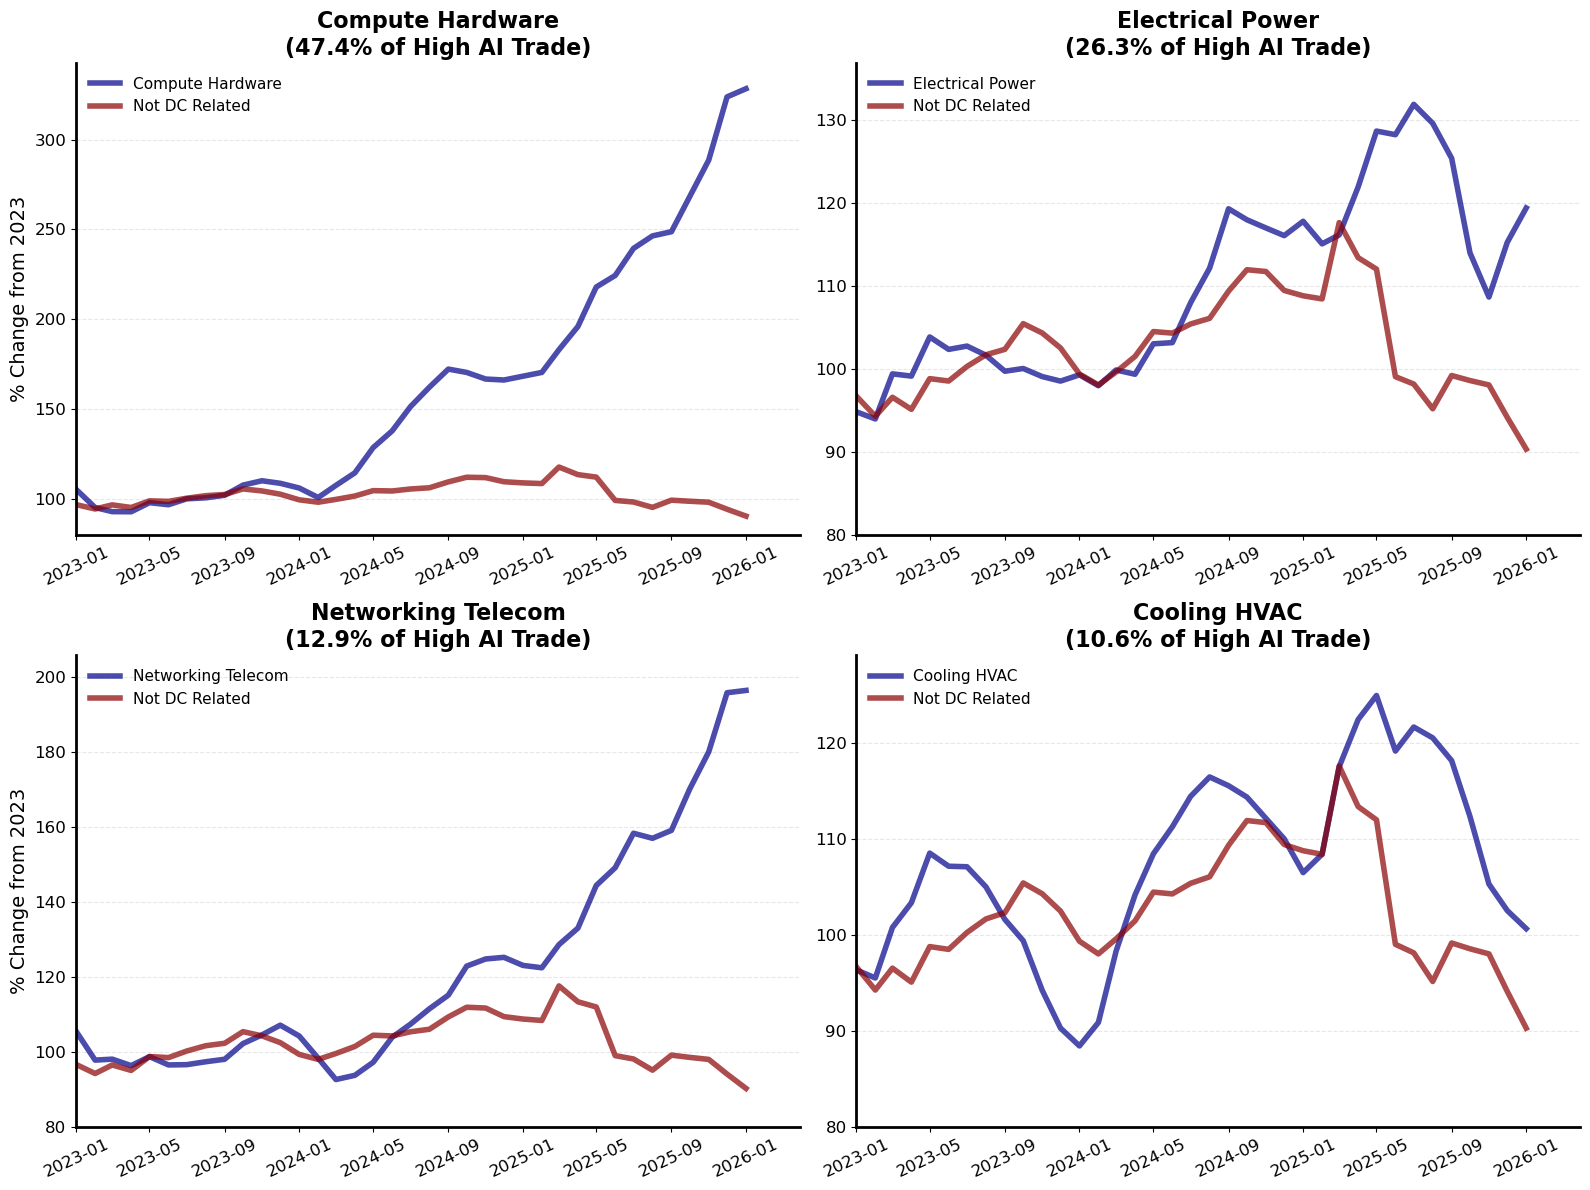

In [17]:
# PLOT TOP 4 CATEGORIES (2x2 panel)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (cat, share) in enumerate(top_categories[:4]):
    ax = axes[idx]
    
    # Get AI category data (High relevance only)
    cat_data = grp_cat_sum[grp_cat_sum['primary_category'] == cat].copy()
    cat_data.set_index('time', inplace=True)
    
    # Normalize to 2023 = 100
    if len(cat_data) > 0 and '2023' in cat_data.index:
        cat_2023_sum = cat_data["imports"].loc["2023"].sum()
        ax.plot(cat_data.index, (100*(12*cat_data["imports"] / cat_2023_sum)).rolling(window=3).mean(),
                color="darkblue", alpha=0.7, linewidth=4, label=cat.replace('_', ' '))
    
    # Plot Not_DC_Related data (all relevance levels)
    if len(not_dc_sum) > 0 and '2023' in not_dc_sum.index:
        not_dc_2023_sum = not_dc_sum["imports"].loc["2023"].sum()
        ax.plot(not_dc_sum.index, (100*(12*not_dc_sum["imports"] / not_dc_2023_sum)).rolling(window=3).mean(),
                color="darkred", alpha=0.7, linewidth=4, label='Not DC Related')
    
    # Formatting
    ax.set_title(f"{cat.replace('_', ' ')}\n({share:.1f}% of High AI Trade)", 
                 fontsize=16, fontweight='bold')
    ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2026,3,30)])
    ax.set_ylim(80,)
    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=12)
    
    if idx >= 2:  # Bottom row
        ax.set_xlabel("")
    if idx % 2 == 0:  # Left column
        ax.set_ylabel("% Change from 2023", fontsize=14)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    
    ax.legend(fontsize=11, frameon=False, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()